# Day 2 — Feature Engineering

Setelah kemarin kita belajar tentang **Data Cleansing** (missing values, outlier, imputation), hari ini kita masuk ke tahap berikutnya yang sangat krusial sebelum melatih model machine learning:

**Feature Engineering** — proses mengubah data mentah menjadi fitur-fitur yang lebih informatif dan siap digunakan oleh algoritma machine learning.

---

## Agenda Hari Ini

1. **Feature Engineering** — Apa itu dan mengapa penting?
2. **Feature Extraction** — Menggali informasi baru dari data yang sudah ada
   - Dari teks
   - Dari numerik
   - Dari tanggal/waktu
3. **Feature Transformation** — Mengubah bentuk fitur agar lebih optimal
   - Scaling
   - Binning
   - Encoding
4. **Feature Selection** — Memilih fitur yang benar-benar relevan

---

Dataset yang digunakan:
- **`telco_raw.csv`** — Data pelanggan telekomunikasi, target: prediksi churn (pelanggan berhenti berlangganan)
- **`sales_data_latihan.csv`** — Data penjualan, untuk latihan ekstraksi dari teks

## [0] Setup & Load Data

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load datasets
telco = pd.read_csv('data/telco_raw.csv')
sales = pd.read_csv('data/sales_data_latihan.csv')

print('Telco shape:', telco.shape)
print('Sales shape:', sales.shape)

Telco shape: (7043, 22)
Sales shape: (10, 6)


In [96]:
# Helper function untuk EDA

class EDAPlotter:
    def __init__(self, df, nrows=1, ncols=1, figsize=(10, 5)):
        self.df = df
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)

        if nrows * ncols == 1:
            self.axes = [self.axes]
        else:
            self.axes = self.axes.flatten()

        self.current_ax = 0

    def _next_ax(self):
        if self.current_ax >= len(self.axes):
            raise IndexError("Jumlah plot melebihi jumlah axes yang tersedia")

        ax = self.axes[self.current_ax]
        self.current_ax += 1
        return ax

    # ======================
    # CATEGORICAL
    # ======================

    def bar(self, column, title, xlabel,
            ylabel='Jumlah', color='steelblue',
            rotation=0, sort_index=True):

        ax = self._next_ax()

        data = self.df.groupby(column).size()
        if sort_index:
            data = data.sort_index()

        data.plot(kind='bar', ax=ax, color=color)

        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis='x', rotation=rotation)

        return self

    def cross_bar(self, index_col, column_col, title, xlabel,
                  ylabel='Count', colormap='Set2', rotation=0):

        ax = self._next_ax()

        data = (
            self.df
            .groupby([index_col, column_col])
            .size()
            .unstack(fill_value=0)
        )

        data.plot(kind='bar', ax=ax, colormap=colormap)

        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis='x', rotation=rotation)
        ax.legend(title=column_col)

        return self

    def rate(self, group_col, calc_func, title, xlabel, ylabel,
             color=None, rotation=0, order=None):

        ax = self._next_ax()

        data = self.df.groupby(group_col).apply(calc_func)

        if order:
            data = data.reindex(order)

        data.plot(kind='bar', ax=ax, color=color)

        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis='x', rotation=rotation)

        return data

    # ======================
    # NUMERICAL
    # ======================

    def hist(self, series, title, bins=30,
             color='steelblue', xlabel=None):

        ax = self._next_ax()

        series.hist(bins=bins, ax=ax,
                    color=color, edgecolor='white')

        ax.set_title(title)
        if xlabel:
            ax.set_xlabel(xlabel)

        return self

    def scaling_compare(self, original, minmax, standard,
                        col, bins=30):

        # 3 plot sekaligus
        self.hist(original[col], f'Original: {col}', bins=bins, color='steelblue')
        self.hist(minmax[f'{col}_minmax'], f'MinMax: {col}', bins=bins, color='green')
        self.hist(standard[f'{col}_standard'], f'Standard: {col}', bins=bins, color='coral')

        return self
    
    def multi_rate(
        self,
        columns,
        calc_func,
        titles,
        color='salmon',
        edgecolor=None,
        rotation=30,
        ylabel='Rate (%)'
    ):
        for col, title in zip(columns, titles):
            ax = self._next_ax()

            data = self.df.groupby(col, observed=True).apply(calc_func)

            data.plot(
                kind='bar',
                ax=ax,
                color=color,
                edgecolor=edgecolor
            )

            ax.set_title(title)
            ax.set_xlabel('')
            ax.set_ylabel(ylabel)
            ax.tick_params(axis='x', rotation=rotation)

        return self

    # ======================
    # FINALIZE
    # ======================

    def show(self, suptitle=None):
        if suptitle:
            self.fig.suptitle(suptitle, y=1.02)

        plt.tight_layout()
        plt.show()

In [72]:
telco.head()

,id,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Stayed
1,1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,Stayed
2,2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Churned
3,3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Stayed
4,4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Churned


---

## [1] Feature Engineering — Konsep Dasar

**Feature Engineering** adalah proses menggunakan pengetahuan domain (*domain knowledge*) untuk membuat, mengubah, atau memilih fitur dari data mentah sehingga model machine learning dapat belajar dengan lebih efektif.

### [1.1] Mengapa Penting?

> *"Applied machine learning is basically feature engineering."*  
> — Andrew Ng

Model machine learning hanya bisa belajar dari angka. Data mentah seringkali mengandung informasi yang tersembunyi dalam format yang tidak langsung bisa dibaca model. Feature engineering bertugas "menerjemahkan" informasi itu.

### [1.2] Tiga Aktivitas Utama

| Aktivitas | Pertanyaan | Contoh |
|---|---|---|
| **Feature Extraction** | Informasi apa yang bisa kita *gali* dari kolom ini? | Dari `tenure` → kategori pelanggan baru/lama |
| **Feature Transformation** | Bagaimana *mengubah bentuk* fitur agar lebih optimal? | Normalisasi `MonthlyCharges` ke skala 0–1 |
| **Feature Selection** | Fitur mana yang *benar-benar berkontribusi* pada prediksi? | Buang fitur yang korelasi rendah dengan `Churn` |

---

## [2] Feature Extraction

Feature Extraction adalah proses **membuat fitur baru** dari fitur yang sudah ada. Kita tidak menghapus data, tapi kita menggali lebih dalam untuk menemukan pola yang lebih eksplisit.

### [2.1] Ekstraksi dari Teks

Dataset `sales_data_latihan.csv` menyimpan nilai penjualan dalam format string seperti `"Rp162500000"` dan pertumbuhan seperti `"30.00%"`. Model tidak bisa membaca format ini — kita perlu mengekstrak angkanya.

In [74]:
sales.head(10)

sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Customer Number  10 non-null     int64
 1   Customer Name    10 non-null     str  
 2   Address          10 non-null     str  
 3   Type             10 non-null     str  
 4   Sales            10 non-null     str  
 5   Percent Growth   9 non-null      str  
dtypes: int64(1), str(5)
memory usage: 612.0 bytes


In [81]:
# Cek tipe data — Sales dan Percent Growth masih object/str
print(sales.dtypes)
print()
print('Contoh nilai Sales:', sales['Sales'].unique()[:10])
print('Contoh nilai Percent Growth:', sales['Percent Growth'].unique()[:10])

Customer Number    int64
Customer Name        str
Address              str
Type                 str
Sales                str
Percent Growth       str
dtype: object

Contoh nilai Sales: <StringArray>
[    'Rp162500000',     'Rp101200000',        '62500000',         '4900000',
      'Rp12750000',     'Rp762500000', 'Rp12,200,000.00',        '50000000',
       'Rp9000000',       '127450000']
Length: 10, dtype: str
Contoh nilai Percent Growth: <StringArray>
['30.00%', '10.00%', nan, '4.00%', '-15.00%', '25']
Length: 6, dtype: str


In [88]:
sales_clean = sales.copy()

# Hapus prefix 'Rp' dan konversi ke numerik
# str.replace() dengan regex=True untuk menghapus karakter non-digit
sales_clean['Sales_numeric'] = (
    sales_clean['Sales']
    .astype(str)
    .str.replace('Rp', '', regex=False)   # hapus 'Rp'
    .str.replace(r'\.\d+', '', regex=True)  # hapus titik dan angka setelahnya (jika ada)
    .str.replace(',', '', regex=False)    # hapus pemisah ribuan jika ada
    .str.strip()
    .apply(pd.to_numeric, errors='coerce') # konversi ke float
)

# Hapus suffix '%' dan konversi ke numerik
sales_clean['Growth_numeric'] = (
    sales_clean['Percent Growth']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.strip()
    .apply(pd.to_numeric, errors='coerce')
)

print('Sebelum:')
print(sales[['Sales', 'Percent Growth']].head(5))
print()
print('Sesudah:')
print(sales_clean[['Sales', 'Sales_numeric', 'Percent Growth', 'Growth_numeric']].head(10))
# print(sales_clean[['Sales', 'Sales_numeric']].head(10))

Sebelum:
         Sales Percent Growth
0  Rp162500000         30.00%
1  Rp101200000         10.00%
2     62500000            NaN
3      4900000          4.00%
4   Rp12750000        -15.00%

Sesudah:
             Sales  Sales_numeric Percent Growth  Growth_numeric
0      Rp162500000      162500000         30.00%            30.0
1      Rp101200000      101200000         10.00%            10.0
2         62500000       62500000            NaN             NaN
3          4900000        4900000          4.00%             4.0
4       Rp12750000       12750000        -15.00%           -15.0
5      Rp762500000      762500000         30.00%            30.0
6  Rp12,200,000.00       12200000         10.00%            10.0
7         50000000       50000000             25            25.0
8        Rp9000000        9000000          4.00%             4.0
9        127450000      127450000        -15.00%           -15.0


In [89]:
# Ekstraksi kolom alamat
sales_clean['Address'].unique()[:10]

# ['Kebayoran Lama', 'Jakarta'] -> setelah split
# [-1] -> ambil elemen terakhir (nama kota)

<StringArray>
['Kebayoran Lama, Jakarta',        'Pasteur, Bandung',
      'Cilincing, Jakarta',       'Antapani, Bandung',
         'Sawangan, Depok', 'Kebayoran Baru, Jakarta',
      'Sleman, Jogjakarta']
Length: 7, dtype: str

In [90]:
# Ekstraksi dari teks Address: ambil kota (kata terakhir setelah koma)
sales_clean['City'] = (
    sales_clean['Address']
    .str.split(',')
    .str[-1]
    .str.strip()
)

print('Address → City:')
print(sales_clean[['Address', 'City']].head(8))

Address → City:
                   Address     City
0  Kebayoran Lama, Jakarta  Jakarta
1         Pasteur, Bandung  Bandung
2  Kebayoran Lama, Jakarta  Jakarta
3         Pasteur, Bandung  Bandung
4       Cilincing, Jakarta  Jakarta
5        Antapani, Bandung  Bandung
6          Sawangan, Depok    Depok
7  Kebayoran Baru, Jakarta  Jakarta


In [91]:
sales_clean['City'].unique()[:10]

array(['Jakarta', 'Bandung', 'Depok', 'Jogjakarta'], dtype=object)

**Takeaway:** Data teks seringkali menyembunyikan informasi numerik atau kategorik yang berguna. Langkah pertama selalu: kenali formatnya, lalu bersihkan dan ekstrak.

### [2.2] Ekstraksi dari Kolom Numerik

Kembali ke dataset `telco_raw.csv`. Kolom `TotalCharges` disimpan sebagai string padahal isinya angka. Selain mengkonversi, kita juga bisa menghitung fitur baru dari kombinasi kolom numerik.

In [92]:
# Informasi dari data telco
print('Telco info:')
print(telco.dtypes)

Telco info:
id                    int64
customerID              str
gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [93]:
df = telco.copy()

# TotalCharges masih string — konversi ke numerik
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('TotalCharges dtype setelah konversi:', df['TotalCharges'].dtype)
print('Missing setelah konversi:', df['TotalCharges'].isna().sum())

# Isi missing dengan 0 (pelanggan baru belum ada tagihan)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

TotalCharges dtype setelah konversi: float64
Missing setelah konversi: 11


In [ ]:
def calculate_avg_monthly_charges(row):
    if row['tenure'] > 0: # digunakan untuk menghindari pembagian dengan nol error 
        return row['TotalCharges'] / row['tenure']
    else:
        return 0
        

In [94]:
telco.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                7043 non-null   int64  
 1   customerID        7043 non-null   str    
 2   gender            7043 non-null   str    
 3   SeniorCitizen     7043 non-null   str    
 4   Partner           7043 non-null   str    
 5   Dependents        7043 non-null   str    
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   str    
 8   MultipleLines     7043 non-null   str    
 9   InternetService   7043 non-null   str    
 10  OnlineSecurity    7043 non-null   str    
 11  OnlineBackup      7043 non-null   str    
 12  DeviceProtection  7043 non-null   str    
 13  TechSupport       7043 non-null   str    
 14  StreamingTV       7043 non-null   str    
 15  StreamingMovies   7043 non-null   str    
 16  Contract          7043 non-null   str    
 17  Paperl

In [95]:
# Fitur baru: Rata-rata tagihan per bulan dibanding total
# Ini mendeteksi apakah ada perubahan pola penggunaan
# df['AvgMonthlyCharge'] = df.apply(
#     lambda row: row['TotalCharges'] / row['tenure'] if row['tenure'] > 0 else 0,
#     axis=1
# )
df['AvgMonthlyCharge'] = df.apply(calculate_avg_monthly_charges, axis=1)

# Fitur baru: Selisih antara tagihan bulan ini vs rata-rata historis
# Nilai positif = tagihan naik; nilai negatif = tagihan turun
df['ChargeDeviation'] = df['MonthlyCharges'] - df['AvgMonthlyCharge']

# Fitur baru: Kategori masa berlangganan
def tenure_group(t):
    if t <= 12:
        return 'New'       # 0-12 bulan
    elif t <= 36:
        return 'Regular'   # 1-3 tahun
    else:
        return 'Loyal'     # > 3 tahun

df['TenureGroup'] = df['tenure'].apply(tenure_group)

# Fitur baru: Kategori masa berlangganan (versi binned)
df['TenureGroup_bin'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 36, float('inf')],
    labels=['New', 'Regular', 'Loyal']
)

print(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyCharge', 'ChargeDeviation', 'TenureGroup', 'TenureGroup_bin']].head(8))

   tenure  MonthlyCharges  TotalCharges  AvgMonthlyCharge  ChargeDeviation  \
0       1           29.85         29.85         29.850000         0.000000   
1      34           56.95       1889.50         55.573529         1.376471   
2       2           53.85        108.15         54.075000        -0.225000   
3      45           42.30       1840.75         40.905556         1.394444   
4       2           70.70        151.65         75.825000        -5.125000   
5       8           99.65        820.50        102.562500        -2.912500   
6      22           89.10       1949.40         88.609091         0.490909   
7      10           29.75        301.90         30.190000        -0.440000   

  TenureGroup TenureGroup_bin  
0         New             New  
1     Regular         Regular  
2         New             New  
3       Loyal           Loyal  
4         New             New  
5         New             New  
6     Regular         Regular  
7         New             New  


In [ ]:
df.groupby('TenureGroup').apply(
    lambda x: (x['Churn'] == 'Churned').mean() * 100
).reindex(['New', 'Regular', 'Loyal'])

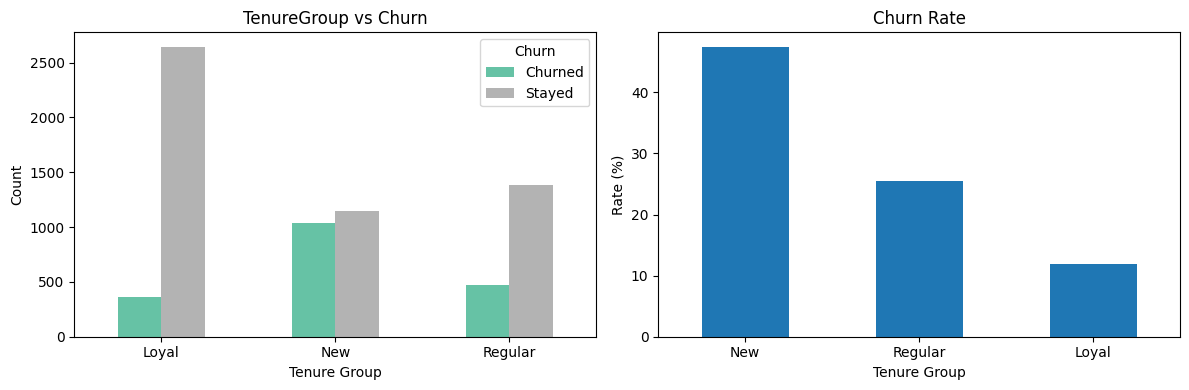

In [97]:
# --- PLOT TENURE GROUP VS CHURN ---
plotter = EDAPlotter(df, 1, 2, (12, 4))

plotter.cross_bar(
    'TenureGroup', 'Churn',
    'TenureGroup vs Churn', 'Tenure Group'
)

churn_rate = plotter.rate(
    'TenureGroup',
    lambda x: (x['Churn'] == 'Churned').mean() * 100,
    'Churn Rate',
    'Tenure Group',
    'Rate (%)',
    order=['New', 'Regular', 'Loyal']
)

plotter.show()

**Insight:** Pelanggan baru (*New*, 0–12 bulan) memiliki churn rate tertinggi. Fitur `TenureGroup` lebih mudah diinterpretasi model dibanding nilai `tenure` mentah.

**Takeaway:** Feature extraction dari numerik bisa berupa:
- **Konversi tipe data** (string → float)
- **Fitur turunan** (kombinasi dua kolom → insight baru)
- **Bucketing / Grouping** (nilai kontinu → kategori bermakna)

### [2.3] Ekstraksi dari Tanggal/Waktu

Dataset telco tidak memiliki kolom datetime, jadi kita akan membuat data sintetis untuk mendemonstrasikan teknik ini. Dalam konteks nyata, kolom tanggal sering muncul sebagai `signup_date`, `last_transaction_date`, `order_date`, dll.

In [98]:
# Buat data sintetis: simulasi signup_date untuk pelanggan telco
np.random.seed(442)
n = len(df)

# Tanggal referensi: anggap data diambil per 2024-01-01
reference_date = pd.Timestamp('2024-01-01')

# Hitung signup_date dari tenure (dalam bulan)
df['signup_date'] = df['tenure'].apply(
    lambda t: reference_date - pd.DateOffset(months=int(t))
)

# Tambah variasi hari dalam bulan (1–28) secara acak
df['signup_date'] = df['signup_date'] + pd.to_timedelta(
    np.random.randint(0, 28, size=n), unit='D'
)

print('Contoh signup_date:')
print(df[['customerID', 'tenure', 'signup_date']].head(8))

Contoh signup_date:
   customerID  tenure signup_date
0  7590-VHVEG       1  2023-12-03
1  5575-GNVDE      34  2021-03-13
2  3668-QPYBK       2  2023-11-14
3  7795-CFOCW      45  2020-04-05
4  9237-HQITU       2  2023-11-10
5  9305-CDSKC       8  2023-05-14
6  1452-KIOVK      22  2022-03-27
7  6713-OKOMC      10  2023-03-12


In [99]:
# Ekstraksi fitur dari datetime
df['signup_year']    = df['signup_date'].dt.year
df['signup_month']   = df['signup_date'].dt.month
df['signup_quarter'] = df['signup_date'].dt.quarter
df['signup_dayofweek'] = df['signup_date'].dt.dayofweek  # 0=Senin, 6=Minggu
df['is_weekend_signup'] = (df['signup_dayofweek'] >= 5).astype(int)

# Lama berlangganan dalam hari (lebih presisi dari tenure bulan)
df['days_active'] = (reference_date - df['signup_date']).dt.days

print('Fitur datetime yang diekstrak:')
print(df[['signup_date', 'signup_year', 'signup_month', 'signup_quarter', 
          'signup_dayofweek', 'is_weekend_signup', 'days_active']].head(8))

Fitur datetime yang diekstrak:
  signup_date  signup_year  signup_month  signup_quarter  signup_dayofweek  \
0  2023-12-03         2023            12               4                 6   
1  2021-03-13         2021             3               1                 5   
2  2023-11-14         2023            11               4                 1   
3  2020-04-05         2020             4               2                 6   
4  2023-11-10         2023            11               4                 4   
5  2023-05-14         2023             5               2                 6   
6  2022-03-27         2022             3               1                 6   
7  2023-03-12         2023             3               1                 6   

   is_weekend_signup  days_active  
0                  1           29  
1                  1         1024  
2                  0           48  
3                  1         1366  
4                  0           52  
5                  1          232  
6             

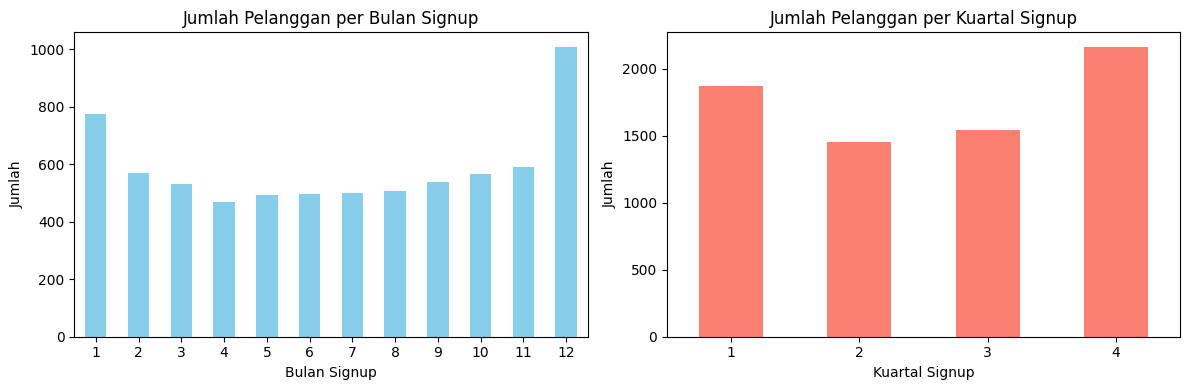

In [100]:
plotter = EDAPlotter(df, nrows=1, ncols=2, figsize=(12, 4))

plotter \
    .bar(
        column='signup_month',
        title='Jumlah Pelanggan per Bulan Signup',
        xlabel='Bulan Signup',
        color='skyblue'
    ) \
    .bar(
        column='signup_quarter',
        title='Jumlah Pelanggan per Kuartal Signup',
        xlabel='Kuartal Signup',
        color='salmon'
    ) \
    .show()

**Takeaway:** Dari satu kolom tanggal, kita bisa menghasilkan banyak fitur:
- `year`, `month`, `quarter` → menangkap tren musiman
- `dayofweek` → apakah hari kerja atau akhir pekan?
- `days_active` → durasi presisi sebagai fitur kontinu

---

## [3] Feature Transformation

Feature Transformation adalah proses **mengubah nilai** dari fitur yang sudah ada agar memiliki distribusi atau representasi yang lebih baik untuk model.

> Tidak semua algoritma sensitif terhadap skala, tapi banyak yang sangat bergantung padanya (KNN, SVM, Neural Network, Gradient Descent-based models).

### [3.1] Scaling

**Masalah:** Kolom `tenure` (0–72) dan `MonthlyCharges` (9–1290) berada di skala yang sangat berbeda. Jika langsung digunakan, model bisa salah menginterpretasi kolom dengan nilai besar sebagai lebih "penting".

**Solusi:** Scaling — menyeragamkan skala semua fitur numerik.

| Metode | Formula | Hasil | Kapan Digunakan |
|---|---|---|---|
| **Min-Max** | (x - min) / (max - min) | 0 sampai 1 | Data tidak berdistribusi normal, tidak ada outlier ekstrem |
| **Standard (Z-score)** | (x - mean) / std | Mean=0, Std=1 | Data mendekati normal, ada outlier |
| **Robust** | (x - median) / IQR | Berbasis median | Data dengan banyak outlier |

In [102]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Pilih kolom numerik untuk scaling
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_num = df[num_cols].copy()

# Terapkan ketiga metode
df_minmax   = pd.DataFrame(MinMaxScaler().fit_transform(df_num),   columns=[c + '_minmax'   for c in num_cols])
df_standard = pd.DataFrame(StandardScaler().fit_transform(df_num), columns=[c + '_standard' for c in num_cols])
df_robust   = pd.DataFrame(RobustScaler().fit_transform(df_num),   columns=[c + '_robust'   for c in num_cols])

print('Sebelum scaling:')
print(df_num.describe().round(2))
print()
print('Setelah MinMaxScaler:')
print(df_minmax.describe().round(3))
print()
print('Setelah StandardScaler:')
print(df_standard.describe().round(3))
print('Setelah RobustScaler:')
print(df_robust.describe().round(3))

Sebelum scaling:
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.92       2279.73
std      24.56           33.45       2266.79
min       0.00            9.20          0.00
25%       9.00           35.50        398.55
50%      29.00           70.35       1394.55
75%      55.00           89.85       3786.60
max      72.00         1290.00       8684.80

Setelah MinMaxScaler:
       tenure_minmax  MonthlyCharges_minmax  TotalCharges_minmax
count       7043.000               7043.000             7043.000
mean           0.450                  0.044                0.262
std            0.341                  0.026                0.261
min            0.000                  0.000                0.000
25%            0.125                  0.021                0.046
50%            0.403                  0.048                0.161
75%            0.764                  0.063                0.436
max            1.000               

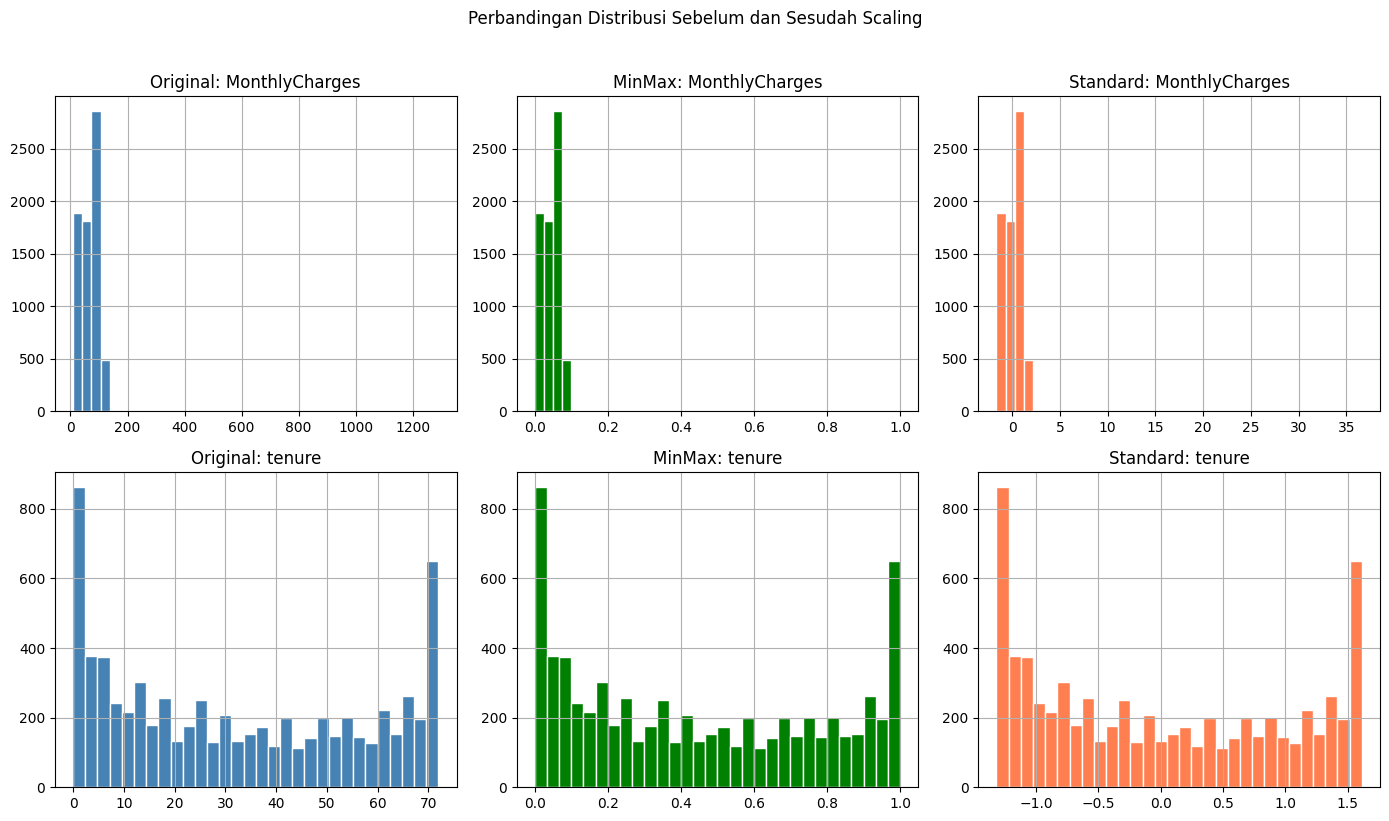

In [103]:
plotter = EDAPlotter(df, 2, 3, (14, 8))

plotter.scaling_compare(df, df_minmax, df_standard, 'MonthlyCharges', bins=40)
plotter.scaling_compare(df, df_minmax, df_standard, 'tenure', bins=30)

plotter.show('Perbandingan Distribusi Sebelum dan Sesudah Scaling')

**Catatan penting:** Scaling **tidak mengubah bentuk distribusi**, hanya mengubah skala. Jika data asli skewed, setelah di-scale tetap skewed.

### [3.2] Binning

**Binning** adalah teknik mengubah variabel **kontinu** menjadi **kategorik** dengan cara membagi rentang nilainya ke dalam beberapa kelompok (bins).

**Kapan digunakan?**
- Ketika hubungan antara fitur dan target tidak linier
- Untuk mengurangi pengaruh outlier
- Ketika interpretasi kategorik lebih bermakna secara bisnis

Ada dua pendekatan:
- **Equal-width binning** (`pd.cut`): Lebar setiap bin sama
- **Equal-frequency binning / Quantile** (`pd.qcut`): Jumlah data di setiap bin sama

In [105]:
# Equal-width binning: MonthlyCharges dibagi 4 kelompok sama lebar
df['Charge_bin_equalwidth'] = pd.cut(
    df['MonthlyCharges'],
    bins=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

# Equal-frequency binning (quantile): masing-masing bin berisi jumlah data yang sama
df['Charge_bin_quantile'] = pd.qcut(
    df['MonthlyCharges'],
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4'],
    duplicates='drop'
)

# Custom binning berdasarkan pengetahuan domain
df['Charge_bin_custom'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 65, 95, 300, float('inf')],
    labels=['Budget', 'Standard', 'Premium', 'Enterprise', 'Whale']
)

print('Distribusi Equal-Width Bins:')
print(df['Charge_bin_equalwidth'].value_counts().sort_index())
print()
print('Distribusi Quantile Bins:')
print(df['Charge_bin_quantile'].value_counts().sort_index())
print()
print('Distribusi Custom Bins:')
print(df['Charge_bin_custom'].value_counts().sort_index())

Distribusi Equal-Width Bins:
Charge_bin_equalwidth
Low          7042
Medium          0
High            0
Very High       1
Name: count, dtype: int64

Distribusi Quantile Bins:
Charge_bin_quantile
Q1    1763
Q2    1766
Q3    1755
Q4    1759
Name: count, dtype: int64

Distribusi Custom Bins:
Charge_bin_custom
Budget        1736
Standard      1409
Premium       2602
Enterprise    1295
Whale            1
Name: count, dtype: int64


In [ ]:
# Visualisasi: Churn rate per bin
plotter = EDAPlotter(df, 1, 3, (15, 4))

plotter.multi_rate(
    columns=[
        'Charge_bin_equalwidth',
        'Charge_bin_quantile',
        'Charge_bin_custom'
    ],
    calc_func=lambda x: (x['Churn'] == 'Churned').mean() * 100,
    titles=[
        'Churn Rate\nEqual-Width Bins',
        'Churn Rate\nQuantile Bins',
        'Churn Rate\nCustom Bins (Domain Knowledge)'
    ],
    color='salmon',
    edgecolor='darkred'
)

plotter.show('Perbandingan Metode Binning — Churn Rate per Kelompok Tagihan')

**Insight:** Custom binning berbasis domain knowledge seringkali menghasilkan kelompok yang lebih bermakna secara bisnis dibanding equal-width atau quantile.

### [3.3] Encoding

Model machine learning hanya bisa menerima input numerik. Kolom kategorik seperti `gender`, `Contract`, `PaymentMethod` harus dikonversi ke angka — proses ini disebut **encoding**.

| Metode | Kapan Digunakan | Contoh Kolom |
|---|---|---|
| **Label Encoding** | Variabel ordinal (ada urutan) | `Contract`: Month < One year < Two year |
| **Binary Encoding** | Variabel biner (2 nilai) | `gender`, `Partner`, `Churn` |
| **One-Hot Encoding** | Variabel nominal (tidak ada urutan, ≤10 kategori) | `PaymentMethod`, `InternetService` |

In [ ]:
df_enc = df.copy()

# --- Binary Encoding ---
# Kolom dengan nilai Yes/No atau Female/Male → 0/1
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 
               'PaperlessBilling', 'SeniorCitizen', 'Churn']

binary_map = {
    'gender':           {'Male': 1, 'Female': 0},
    'Partner':          {'Yes': 1, 'No': 0},
    'Dependents':       {'Yes': 1, 'No': 0},
    'PhoneService':     {'Yes': 1, 'No': 0},
    'PaperlessBilling': {'Yes': 1, 'No': 0},
    'SeniorCitizen':    {'Yes': 1, 'No': 0},
    'Churn':            {'Churned': 1, 'Stayed': 0},
}

for col, mapping in binary_map.items():
    df_enc[col] = df_enc[col].map(mapping)

print('Binary encoding selesai:')
print(df_enc[['gender', 'Partner', 'Churn']].head(5))

In [ ]:
# Contract memiliki 3 kategori: Month-to-month, One year, Two year
df_enc['Contract'].unique()

In [ ]:
# --- Label Encoding untuk kolom ordinal ---
contract_order = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df_enc['Contract_encoded'] = df_enc['Contract'].map(contract_order)

print('Label encoding untuk Contract:')
print(df_enc[['Contract', 'Contract_encoded']].value_counts().reset_index().sort_values('Contract_encoded'))

In [ ]:
# --- One-Hot Encoding untuk kolom nominal ---
# PaymentMethod dan InternetService: tidak ada urutan inherent

# Normalisasi dulu: 'dsl' → 'DSL' (ada inkonsistensi di data)
df_enc['InternetService'] = df_enc['InternetService'].str.upper().str.strip()

ohe_cols = ['InternetService', 'PaymentMethod']
df_enc = pd.get_dummies(df_enc, columns=ohe_cols, prefix=ohe_cols, drop_first=False)

# Tampilkan kolom hasil OHE
new_cols = [c for c in df_enc.columns if c.startswith('InternetService_') or c.startswith('PaymentMethod_')]
print('Kolom hasil One-Hot Encoding:')
print(new_cols)
print()
print(df_enc[new_cols].head(5))

In [ ]:
# Ringkasan kolom setelah encoding
print('Shape sebelum encoding:', df.shape)
print('Shape setelah encoding :', df_enc.shape)
print()
print('Tipe data numerik semua?')
print(df_enc.select_dtypes(include=['object', 'category']).columns.tolist())

**Takeaway:**
- Gunakan **binary encoding** untuk variabel dengan 2 nilai (hemat kolom)
- Gunakan **label encoding** hanya untuk variabel ordinal (ada urutan)
- Gunakan **one-hot encoding** untuk variabel nominal (buat kolom biner baru per kategori)
- **Jangan** pakai label encoding untuk variabel nominal — model akan salah mengasumsikan ada urutan!

### [3.4] Tambahan: Skewed Distribution

Distribusi yang sangat skewed dapat menurunkan performa model linear. Kita deteksi kolom numerik yang miring, lalu coba dua pendekatan koreksi: `log1p` (simple & interpretable) dan `PowerTransformer` Yeo-Johnson (robust untuk nilai nol/negatif).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
            'AvgMonthlyCharge', 'ChargeDeviation', 'days_active']

skewness = df[num_cols].skew().sort_values(ascending=False)
print('Skewness per kolom:')
print(skewness.to_string())
print('\nKolom dengan |skew| > 0.5 (kandidat transform):')
skewed_cols = skewness[skewness.abs() > 0.5].index.tolist()
print(skewed_cols)

In [ ]:
pt = PowerTransformer(method='yeo-johnson', standardize=False)

for col in skewed_cols:
    original = df[col].dropna()
    log_tr   = np.log1p(original)
    yj_tr    = pd.Series(
        pt.fit_transform(original.values.reshape(-1, 1)).flatten()
    )

    fig, axes = plt.subplots(1, 3, figsize=(13, 3))
    fig.suptitle(f'Kolom: {col}  |  Skew awal: {original.skew():.3f}', fontsize=12)

    axes[0].hist(original, bins=40, color='steelblue', edgecolor='white')
    axes[0].set_title(f'Original  (skew={original.skew():.2f})')

    axes[1].hist(log_tr, bins=40, color='seagreen', edgecolor='white')
    axes[1].set_title(f'log1p  (skew={log_tr.skew():.2f})')

    axes[2].hist(yj_tr, bins=40, color='tomato', edgecolor='white')
    axes[2].set_title(f'Yeo-Johnson  (skew={yj_tr.skew():.2f})')

    plt.tight_layout()
    plt.show()

**Kapan pakai apa?**

| Metode | Cocok untuk | Catatan |
|--------|-------------|--------|
| `log1p` | Nilai ≥ 0, distribusi right-skewed | Mudah di-invert, sangat interpretable |
| `PowerTransformer(yeo-johnson)` | Semua nilai termasuk nol/negatif | Lebih fleksibel |
| `PowerTransformer(box-cox)` | Nilai > 0 saja | Versi klasik, tidak bisa handle nol |

> **Penting**: Fit transformer **hanya pada data training**, lalu `.transform()` pada test — dibahas detail di Section 5 (Data Leakage).

### [3.5] Tambahan: Imbalanced Data

Dataset telco churn tidak seimbang: ~73% tidak churn vs ~27% churn. Model yang mengabaikan ini cenderung prediksi kelas mayoritas — accuracy tinggi tapi recall kelas minoritas buruk.

In [ ]:
y = df_enc['Churn']

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print('Distribusi kelas target:')
print(y.value_counts())
print(y.value_counts(normalize=True).mul(100).round(1).to_string())

In [ ]:
X = df_enc[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].fillna(0)

# Split stratified
X_tr_imb, X_te_imb, y_tr_imb, y_te_imb = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessing sederhana untuk demo
imp = SimpleImputer(strategy='median')
sc  = StandardScaler()
X_tr_p = sc.fit_transform(imp.fit_transform(X_tr_imb))
X_te_p = sc.transform(imp.transform(X_te_imb))

# Baseline: selalu prediksi mayoritas
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_tr_p, y_tr_imb)
print('=== DummyClassifier (selalu mayoritas) ===')
print(classification_report(y_te_imb, dummy.predict(X_te_p),
                            target_names=['No Churn', 'Churn']))

# LogisticRegression tanpa penanganan
lr_def = LogisticRegression(max_iter=1000, random_state=42)
lr_def.fit(X_tr_p, y_tr_imb)
print('=== LogisticRegression (default) ===')
print(classification_report(y_te_imb, lr_def.predict(X_te_p),
                            target_names=['No Churn', 'Churn']))

# LogisticRegression dengan class_weight='balanced'
lr_bal = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_bal.fit(X_tr_p, y_tr_imb)
print("=== LogisticRegression (class_weight='balanced') ===")
print(classification_report(y_te_imb, lr_bal.predict(X_te_p),
                            target_names=['No Churn', 'Churn']))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_te_imb, lr_def.predict(X_te_p),
    display_labels=['No Churn', 'Churn'], cmap='Blues', ax=axes[0]
)
axes[0].set_title('Tanpa class_weight')

ConfusionMatrixDisplay.from_predictions(
    y_te_imb, lr_bal.predict(X_te_p),
    display_labels=['No Churn', 'Churn'], cmap='Greens', ax=axes[1]
)
axes[1].set_title("class_weight='balanced'")

plt.suptitle('Confusion Matrix: Perbandingan Penanganan Imbalance', fontsize=12)
plt.tight_layout()
plt.show()

**Strategi penanganan imbalanced data:**

| Strategi | Cara | Kapan |
|----------|------|-------|
| `class_weight='balanced'` | Beri bobot lebih ke kelas minoritas | Paling mudah, coba dulu |
| Oversampling (SMOTE) | Buat sampel sintetis kelas minoritas | Dataset kecil–sedang |
| Undersampling | Kurangi sampel kelas mayoritas | Dataset besar |
| Threshold tuning | Turunkan threshold prediksi (misal 0.3) | Fine-tuning setelah model jadi |

> Untuk imbalanced data, gunakan **F1-score**, **Recall**, atau **AUC-ROC** — bukan hanya accuracy.

---

## [4] Feature Selection

Setelah menghasilkan banyak fitur, kita perlu memilih fitur mana yang **benar-benar relevan** untuk model. Terlalu banyak fitur menyebabkan:
- **Curse of dimensionality** — model sulit generalisasi
- **Overfitting** — model terlalu hafal data training
- **Lambat** — waktu training lebih lama

### [4.1] Pendekatan Feature Selection

| Metode | Cara Kerja | Kelebihan | Kekurangan |
|---|---|---|---|
| **Filter** (Korelasi, Chi-Square) | Evaluasi setiap fitur secara independen | Cepat, mudah dipahami | Tidak memperhitungkan interaksi antar fitur |
| **Wrapper** (RFE) | Iterasi dengan model untuk cari subset terbaik | Akurat | Mahal secara komputasi |
| **Embedded** (Feature Importance) | Seleksi terjadi saat training model | Efisien, memperhitungkan interaksi | Spesifik untuk jenis model tertentu |

In [ ]:
# Persiapkan data untuk feature selection
# Ambil kolom numerik yang sudah clean
feature_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 
    'tenure', 'PhoneService', 'PaperlessBilling',
    'MonthlyCharges', 'TotalCharges', 'Contract_encoded',
    'AvgMonthlyCharge', 'ChargeDeviation', 'days_active'
]

# Tambahkan kolom OHE yang tersedia
ohe_available = [c for c in df_enc.columns if c.startswith('InternetService_') or c.startswith('PaymentMethod_')]
feature_cols += ohe_available

# Filter hanya kolom yang ada dan numerik
feature_cols = [c for c in feature_cols if c in df_enc.columns]
X = df_enc[feature_cols].select_dtypes(include='number').fillna(0)
y = df_enc['Churn']

print('Jumlah fitur kandidat:', X.shape[1])
print('Distribusi target (Churn):')
print(y.value_counts())

### [4.2] Filter Method — Korelasi dengan Target

In [ ]:
# Hitung korelasi Pearson antara setiap fitur dan target (Churn)
correlations = X.corrwith(y).abs().sort_values(ascending=False)

print('Top 15 fitur berdasarkan korelasi dengan Churn:')
print(correlations.head(15).round(4))

In [ ]:
# Visualisasi korelasi
plt.figure(figsize=(10, 6))
top_corr = correlations.head(15)
colors = ['#e74c3c' if v > 0.2 else '#f39c12' if v > 0.1 else '#95a5a6' for v in top_corr.values]
top_corr.plot(kind='barh', color=colors)
plt.axvline(x=0.1, color='orange', linestyle='--', alpha=0.7, label='Threshold 0.1')
plt.axvline(x=0.2, color='red', linestyle='--', alpha=0.7, label='Threshold 0.2')
plt.title('Korelasi Absolut Fitur dengan Target (Churn)')
plt.xlabel('|Korelasi|')
plt.legend()
plt.tight_layout()
plt.show()

### [4.3] Embedded Method — Feature Importance dari Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Latih Random Forest sederhana untuk mendapatkan feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Ambil feature importance
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print('Top 15 fitur berdasarkan Random Forest Feature Importance:')
print(importance_df.head(15).round(4).to_string(index=False))

In [ ]:
# Visualisasi feature importance
plt.figure(figsize=(10, 6))
top_imp = importance_df.head(15)
plt.barh(top_imp['feature'][::-1], top_imp['importance'][::-1], color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### [4.4] Wrapper Method — Recursive Feature Elimination (RFE)

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# RFE membutuhkan fitur yang sudah di-scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# RFE dengan Logistic Regression — pilih 10 fitur terbaik
lr = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=lr, n_features_to_select=10, step=1)
rfe.fit(X_scaled, y)

# Fitur yang dipilih RFE
rfe_selected = X.columns[rfe.support_].tolist()
print('Fitur yang dipilih oleh RFE (10 terbaik):')
for i, f in enumerate(rfe_selected, 1):
    print(f'  {i}. {f}')

### [4.5] Perbandingan Ketiga Metode

In [ ]:
# Ambil top-10 dari masing-masing metode
top10_correlation  = set(correlations.head(10).index.tolist())
top10_rf_importance = set(importance_df.head(10)['feature'].tolist())
top10_rfe          = set(rfe_selected)

# Fitur yang muncul di semua 3 metode (konsensus)
consensus = top10_correlation & top10_rf_importance & top10_rfe

# Buat summary
all_features = top10_correlation | top10_rf_importance | top10_rfe
summary = pd.DataFrame({
    'Feature': list(all_features),
    'Correlation':   [ '✓' if f in top10_correlation  else '' for f in all_features],
    'RF Importance': ['✓' if f in top10_rf_importance else '' for f in all_features],
    'RFE':           ['✓' if f in top10_rfe           else '' for f in all_features],
})
summary['Score'] = (
    (summary['Correlation'] == '✓').astype(int) +
    (summary['RF Importance'] == '✓').astype(int) +
    (summary['RFE'] == '✓').astype(int)
)
summary = summary.sort_values('Score', ascending=False)

print('Perbandingan Fitur Terpilih dari 3 Metode:')
print(summary.to_string(index=False))
print()
print(f'Fitur konsensus (ada di semua 3 metode): {consensus}')

In [ ]:
# Final: pilih fitur terpilih berdasarkan konsensus (muncul di ≥2 metode)
final_features = summary[summary['Score'] >= 2]['Feature'].tolist()
print(f'Fitur final yang dipilih ({len(final_features)} fitur, skor ≥ 2 dari 3 metode):')
for i, f in enumerate(final_features, 1):
    print(f'  {i}. {f}')

X_final = X[final_features]
print(f'\nShape dataset final: {X_final.shape}')

## [5] Tambahan: Data Leakage & Pipeline

Dua topik kritis dalam preprocessing:
1. **Data Leakage** — informasi test set bocor ke training, evaluasi jadi terlalu optimis
2. **Pipeline** — cara robust untuk mengemas preprocessing + model agar leakage-free dan mudah di-deploy

### [5.1] Data Leakage

Leakage terjadi ketika transformer di-`.fit()` pada **seluruh dataset** sebelum split. Transformer 'melihat' statistik test set, sehingga evaluasi tidak mencerminkan performa nyata.

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Demo leakage yang dibuat SENGAJA lebih signifikan:
# target encoding pada customerID. Jika encoding dihitung dari seluruh data,
# maka nilai target test ikut "terlihat" (leakage parah).
base_cols = ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
work = df[base_cols].copy()
work['SeniorCitizen'] = work['SeniorCitizen'].apply(lambda x: 1 if x == 'Yes' else 0)

y_bin = y.astype(int)

# Split SEKALI di awal agar apple-to-apple
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    work, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'te_customer']

# ── CARA SALAH (Leaky) ──────────────────────────────────────────────
# Target encoding customerID dihitung dari SELURUH data (termasuk test)
te_map_leak = y_bin.groupby(work['customerID']).mean()
work_leak = work.copy()
work_leak['te_customer'] = work_leak['customerID'].map(te_map_leak)

# Setelah fitur leaky dibuat, baru split
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(
    work_leak[num_cols], y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

imp_l = KNNImputer(n_neighbors=5)
sc_l = StandardScaler()
Xl_tr_p = sc_l.fit_transform(imp_l.fit_transform(Xl_tr))
Xl_te_p = sc_l.transform(imp_l.transform(Xl_te))

lr_l = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_l.fit(Xl_tr_p, yl_tr)
auc_leak = roc_auc_score(yl_te, lr_l.predict_proba(Xl_te_p)[:, 1])

# ── CARA BENAR (No Leakage) ─────────────────────────────────────────
# Target encoding hanya dari TRAIN; customerID test yang tidak pernah terlihat
# diisi dengan prior train (tanpa info target test)
te_map_ok = y_tr.groupby(X_tr_raw['customerID']).mean()
prior = y_tr.mean()

Xr_tr = X_tr_raw.copy()
Xr_te = X_te_raw.copy()
Xr_tr['te_customer'] = Xr_tr['customerID'].map(te_map_ok).fillna(prior)
Xr_te['te_customer'] = Xr_te['customerID'].map(te_map_ok).fillna(prior)

imp_r = KNNImputer(n_neighbors=5)
sc_r = StandardScaler()
Xr_tr_p = sc_r.fit_transform(imp_r.fit_transform(Xr_tr[num_cols]))
Xr_te_p = sc_r.transform(imp_r.transform(Xr_te[num_cols]))

lr_r = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_r.fit(Xr_tr_p, y_tr)
auc_ok = roc_auc_score(y_te, lr_r.predict_proba(Xr_te_p)[:, 1])

print(f'AUC — Cara SALAH (leaky)  : {auc_leak:.6f}  <- terlalu optimis (leakage berat)')
print(f'AUC — Cara BENAR (no leak): {auc_ok:.6f}  <- estimasi realistis')
print(f'Selisih: {auc_leak - auc_ok:+.6f}')

### [5.2] Pipeline Sederhana

`Pipeline` scikit-learn otomatis menghindari leakage: semua step di-fit hanya saat `.fit()` pada training data, dan hanya di-transform saat `.predict()`.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

simple_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
])

demo_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
df_demo = df.copy()
df_demo['SeniorCitizen'] = df_demo['SeniorCitizen'].transform(lambda x: 1 if x == 'Yes' else 0)
cv_scores = cross_val_score(
    simple_pipe, df_demo[demo_cols], y, cv=5, scoring='roc_auc'
)
print('CV AUC per fold:', cv_scores.round(4))
print(f'Mean AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

### [5.3] Pipeline Lengkap dengan ColumnTransformer

Dataset nyata punya kolom bertipe berbeda. `ColumnTransformer` memungkinkan transformer berbeda per kolom, semuanya dalam satu Pipeline.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

num_feats = ['tenure', 'MonthlyCharges', 'TotalCharges']
bin_feats = ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
ohe_feats = ['InternetService', 'Contract', 'PaymentMethod']

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
bin_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])
ohe_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, num_feats),
    ('bin', bin_pipe, bin_feats),
    ('ohe', ohe_pipe, ohe_feats),
], remainder='drop')

full_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
])

X_ct = df[num_feats + bin_feats + ohe_feats].copy()

# Robust binary coercion
binary_map = {
    'yes': 1, 'no': 0,
    'male': 1, 'female': 0,
    '1': 1, '0': 0,
    'true': 1, 'false': 0
}
for col in bin_feats:
    X_ct[col] = (
        X_ct[col]
        .replace({True: 1, False: 0})
        .astype(str)
        .str.strip()
        .str.lower()
        .map(binary_map)
    )

# Safety net: force numeric; unknown values become NaN and will be imputed
X_ct[bin_feats] = X_ct[bin_feats].apply(pd.to_numeric, errors='coerce')

cv_full = cross_val_score(full_pipe, X_ct, y, cv=5, scoring='roc_auc')
print('ColumnTransformer Pipeline — CV AUC per fold:', cv_full.round(4))
print(f'Mean AUC: {cv_full.mean():.4f} ± {cv_full.std():.4f}')

### [5.4] Simpan & Load Pipeline dengan joblib

Pipeline yang sudah di-fit bisa disimpan ke `.pkl` dan di-load untuk prediksi tanpa training ulang — dasar dari model deployment.

In [ ]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# Fit pada seluruh data setelah CV memuaskan
full_pipe.fit(X_ct, y)

model_path = 'models/churn_pipeline.pkl'
joblib.dump(full_pipe, model_path)
print(f'Pipeline disimpan ke: {model_path}')

# Load kembali dan inferensi
loaded_pipe = joblib.load(model_path)
sample = X_ct.sample(3, random_state=7).reset_index(drop=True)
proba  = loaded_pipe.predict_proba(sample)[:, 1]
pred   = loaded_pipe.predict(sample)

result = sample[num_feats].copy()
result['churn_proba'] = proba.round(3)
result['churn_pred']  = pred
print('\nHasil prediksi sampel pelanggan:')
print(result.to_string(index=False))

---

## [6] Export Data Hasil Preprocessing

Setelah melalui seluruh proses feature engineering, kita simpan dataset yang sudah bersih dan siap pakai ke file **Parquet**.

**Mengapa Parquet?**
- Format kolumnar — pembacaan kolom tertentu jauh lebih cepat dari CSV
- Menyimpan informasi tipe data (tidak perlu konversi ulang)
- Ukuran file jauh lebih kecil dari CSV karena kompresi bawaan
- Standar de-facto untuk pertukaran data di ekosistem data engineering (Spark, Pandas, PyArrow)

In [ ]:
from sklearn.preprocessing import StandardScaler

# --- Susun dataset final yang akan diekspor ---
# Mulai dari df_enc (sudah di-encode) + tambahkan fitur turunan

export_df = df_enc.copy()

# Pastikan fitur turunan dari step sebelumnya ada
derived = ['AvgMonthlyCharge', 'ChargeDeviation', 'TenureGroup',
           'signup_year', 'signup_month', 'signup_quarter',
           'signup_dayofweek', 'is_weekend_signup', 'days_active',
           'Charge_bin_custom']
for col in derived:
    if col in df.columns and col not in export_df.columns:
        export_df[col] = df[col].values

# Sertakan kolom hasil scaling (StandardScaler pada fitur numerik utama)
scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyCharge', 'ChargeDeviation', 'days_active']
scale_cols = [c for c in scale_cols if c in export_df.columns]
scaler_final = StandardScaler()
scaled_values = scaler_final.fit_transform(export_df[scale_cols].fillna(0))
for i, col in enumerate(scale_cols):
    export_df[f'{col}_scaled'] = scaled_values[:, i]

# Hapus kolom non-numerik / helper yang tidak dibutuhkan model
drop_cols = ['id', 'customerID', 'signup_date',
             'TenureGroup', 'Charge_bin_equalwidth',
             'Charge_bin_quantile', 'Charge_bin_custom']
drop_cols = [c for c in drop_cols if c in export_df.columns]
export_df = export_df.drop(columns=drop_cols)

# Pastikan semua kolom numerik (buang sisa object/category)
export_df = export_df.select_dtypes(include='number')

print(f'Shape dataset yang akan diekspor: {export_df.shape}')
print(f'Kolom:')
print(export_df.columns.tolist())
print()
print('Sample data:')
export_df.head()

In [ ]:
import os

output_path = 'data/data_preprocessing_result.parquet'
export_df.to_parquet(output_path, index=False)

file_size_kb = os.path.getsize(output_path) / 1024
print(f'✓ Data berhasil disimpan ke: {output_path}')
print(f'  Jumlah baris  : {len(export_df):,}')
print(f'  Jumlah kolom  : {export_df.shape[1]}')
print(f'  Ukuran file   : {file_size_kb:.1f} KB')
print()

# Verifikasi: baca kembali dan cek
verify = pd.read_parquet(output_path)
print('Verifikasi baca ulang:')
print(f'  Shape         : {verify.shape}')
print(f'  Tipe data OK  : {(verify.dtypes != object).all()}')
print(f'  Missing values: {verify.isna().sum().sum()}')

---

## [7] Ringkasan

### [7.1] Apa yang Kita Pelajari Hari Ini

| Teknik | Tujuan | Contoh yang Kita Lakukan |
|---|---|---|
| **Feature Extraction (Teks)** | Mengambil nilai dari string | Hapus `Rp` dan `%` dari kolom Sales |
| **Feature Extraction (Numerik)** | Membuat fitur baru dari kombinasi numerik | `AvgMonthlyCharge`, `ChargeDeviation`, `TenureGroup` |
| **Feature Extraction (Datetime)** | Menggali komponen dari tanggal | `signup_month`, `signup_quarter`, `days_active` |
| **Scaling** | Menyeragamkan skala fitur numerik | MinMax, Standard, Robust |
| **Binning** | Mengubah kontinu → kategorik | `MonthlyCharges` → Budget/Standard/Premium |
| **Encoding** | Mengubah kategorik → numerik | Binary, Label, One-Hot Encoding |
| **Feature Selection** | Memilih fitur yang paling relevan | Korelasi, RF Importance, RFE |
| **Transformer** | Skewed Distribution | `.skew()`, `log1p`, `PowerTransformer` |
| **Imbalanced Data** | Imbalanced Data | `DummyClassifier`, `class_weight`, confusion matrix |
| **Good Practice**  | Data Leakage & Pipeline | `Pipeline`, `ColumnTransformer`, `joblib` |

### [7.2] Alur Feature Engineering dalam Pipeline ML

```
Data Mentah
    ↓
[Day 1] EDA + Data Cleansing (Missing, Outlier, Imputation)
    ↓
[Day 2] Feature Extraction      → fitur baru dari yang sudah ada
        Feature Transformation  → scale, bin, encode
        Feature Selection       → pilih yang paling relevan
    ↓
Dataset Siap untuk Model ML
```